### Data loading, package installation

In [573]:
# Load the processed_data.csv file
data <- read.csv("data/processed_data.csv")

# Install and load dplyr and purrr packages if not installed
if (!require(dplyr)) install.packages("dplyr")
if (!require(purrr)) install.packages("purrr")
if (!require(readr)) install.packages("readr")
if (!require(zoo)) install.packages("zoo")
if (!require(lubridate)) install.packages("lubridate")
if (!require(xgboost)) install.packages("xgboost")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(yardstick)) install.packages("yardstick")
if (!require(WVPlots)) install.packages("WVPlots")
if (!require(pROC)) install.packages("pROC")
if (!require(caret)) install.packages("caret")
if (!require(tidyr)) install.packages("tidyr")
if (!require(tidytext)) install.packages("tidytext")
library(dplyr)
library(purrr)
library(readr)
library(zoo)
library(lubridate)
library(xgboost)
library(ggplot2)
library(yardstick)
library(WVPlots)
library(pROC)
library(caret)
library(tidyr)
library(tidytext)


### Prepare the dataset for modelling

Sum the "ballots_gained" for each motion on each side, then subtract neg_side from aff_side 

In [574]:
motion_bias <- data %>%
  group_by(tournament_id, motion, aff_side) %>%
  summarise(
    # How many ballots were gained on this side for this motion in this tournament
    ballots_gained_sum = sum(ballots_gained, na.rm = TRUE)/3,
    .groups = "drop"
  ) %>%
  # Pivot to get TRUE/FALSE columns
  pivot_wider(names_from = aff_side, values_from = ballots_gained_sum) %>%
  # Calculate bias as difference
  mutate(aff_bias = `TRUE` - `FALSE`) %>%
  select(tournament_id, motion, aff_bias)

head(motion_bias)

tournament_id,motion,aff_bias
<int>,<chr>,<dbl>
307,Rozvinuté země by měly kompenzovat rozvojovým zemím škody způsobené klimatickou změnou,-4
308,Economic globalization has brought more harm than good to developing countries,-4
308,"In times of crisis, policy decisions should be made by independent experts instead of elected politicians.",0
308,Social justice movements without a prominent leader are preferable to ones with a prominent leader,-4
309,Hotovost by měla být zrušena,0
309,Na ZŠ by se mělo zavést pouze slovní hodnocení.,6


### Add "aff_bias" to the "data"

In [575]:
# Add "aff_bias" to the "data"
data <- data %>%
  left_join(motion_bias, by = c("tournament_id", "motion"))
# Put the column behind the "aff_side" column
data <- data %>%
  relocate(aff_bias, .after = aff_side)

### Modelling and predicting bias

In [576]:
# --- STEP 1: TEXT ANALYSIS (TF-IDF) ---

# Break the motions into individual words and create a feature matrix
motion_words <- motion_bias %>%
  # Use drop = FALSE to keep the original motion column
  unnest_tokens(word, motion, drop = FALSE) %>% 
  count(tournament_id, motion, word) %>% 
  bind_tf_idf(word, motion, n)
cat("Total number of words (nrows):", nrow(motion_words), "\n")

# Create a sparse matrix (does not store zeros) where each column is a word and each row is a unique motion
  # Motion = Rows
  # Word = Columns: Every unique word from your entire vocabulary becomes a single column in the matrix.
  # tf_idf = Values (Cell content)
sparse_data <- motion_words %>%
  cast_sparse(motion, word, tf_idf)
cat("Total number of unique words (ncols):", ncol(sparse_data), "\n")

# Align the bias labels with the sparse matrix rows, keeping one label per motion
label_df <- motion_bias %>%
  distinct(motion, aff_bias)
labels <- label_df$aff_bias[match(rownames(sparse_data), label_df$motion)]
cat("Total number of unique combinations of motions:", length(labels), "\n")

# Create a row-level index linking motions to tournaments
row_index <- motion_bias %>%
  distinct(motion, tournament_id, aff_bias)

# Ensure row order matches sparse_data
row_index <- row_index[match(rownames(sparse_data), row_index$motion), ]
stopifnot(nrow(row_index) == nrow(sparse_data))


Total number of words (nrows): 429 
Total number of unique words (ncols): 298 
Total number of unique combinations of motions: 38 


In [577]:
# --- STEP 2: ROLLING WINDOW TRAINING & TESTING ---

test_ids <- c(317, 318, 319, 320)
results_list <- list()

for (test_id in test_ids) {
  cat("\nProcessing Split: Training 307-", test_id - 1, 
      " | Testing ", test_id, sep = "")
  
  # Row indices for training/testing
  train_rows <- which(row_index$tournament_id >= 307 &
                      row_index$tournament_id <  test_id)
  test_rows  <- which(row_index$tournament_id == test_id)
  
  # Subset sparse matrices
  train_matrix <- sparse_data[train_rows, ]
  test_matrix  <- sparse_data[test_rows, ]
  
  # Labels
  train_labels <- row_index$aff_bias[train_rows]
  test_labels  <- row_index$aff_bias[test_rows]
  
  bst <- suppressWarnings({
      xgboost(
        data = train_matrix,
        label = train_labels,
        max.depth = 8,
        nrounds = 40000,
        eta = 0.05,
        min_child_weight = 5,
        gamma = 1,
        lambda = 2,
        alpha = 0.5,
        subsample = 0.8,
        colsample_bytree = 0.6,
        colsample_bynode = 0.6,
        objective = "reg:squarederror",
        tree_method = "hist",
        verbose = 0
      )
    })
  
  # Predict
  preds <- predict(bst, test_matrix)
  
  # Store results
  results_list[[as.character(test_id)]] <- data.frame(
    tournament_id = test_id,
    motion        = row_index$motion[test_rows],
    actual        = test_labels,
    predicted     = preds
  )
}

# Combine all testing rounds
final_bias_predictions <- bind_rows(results_list)


Processing Split: Training 307-316 | Testing 317
Processing Split: Training 307-317 | Testing 318
Processing Split: Training 307-318 | Testing 319
Processing Split: Training 307-319 | Testing 320

### Show predictions

In [578]:
# Print the final_bias_predictions
final_bias_predictions

,tournament_id,motion,actual,predicted
,<dbl>,<chr>,<dbl>,<dbl>
Long‑term vacant residential buildings and apartments should have their ownership transferred to municipal authorities,317,Long‑term vacant residential buildings and apartments should have their ownership transferred to municipal authorities,9,-3.485252
The narrative that hard work will lead to success brings more harm than good,317,The narrative that hard work will lead to success brings more harm than good,15,-3.485252
The proposed EU Chat control regulation would bring more harm than good,317,The proposed EU Chat control regulation would bring more harm than good,-19,-3.485252
E-sport by se měl stát olympijskou disciplínou,318,E-sport by se měl stát olympijskou disciplínou,26,1.676474
SŠ by měly aktivně podporovat využívání umělé inteligence ve výuce,318,SŠ by měly aktivně podporovat využívání umělé inteligence ve výuce,20,8.124175
"Výchova, ve které má dítě velkou míru autonomie, je lepší než výchova, při níž rozhodují rodiče",318,"Výchova, ve které má dítě velkou míru autonomie, je lepší než výchova, při níž rozhodují rodiče",9,20.204559
"Raději bychom pracovali v dobře placené profesi a většinu svého platu darovali na charitu, než abychom pracovali přímo pro charitu za nižší mzdu.",319,"Raději bychom pracovali v dobře placené profesi a většinu svého platu darovali na charitu, než abychom pracovali přímo pro charitu za nižší mzdu.",13,-7.640316
"Svět, ve kterém všichni interpretují náboženství sami, je lepší než svět, ve kterém je náboženství interpretováno církví",319,"Svět, ve kterém všichni interpretují náboženství sami, je lepší než svět, ve kterém je náboženství interpretováno církví",-3,2.245288
Systém stálého členství v Radě bezpečnosti OSN by měl být zrušen,319,Systém stálého členství v Radě bezpečnosti OSN by měl být zrušen,-6,-11.967233


### Evaluation: RMSE, R-squared, Gain Curve

<span style="color:blue">The model fits the data worse (negative R-squared, RMSE>sd(actual)) than a horizontal line representing the mean of the dependent variable.</span>

<span style="color:blue">We decided that further hyperparameter engineering is not worth it.</span>

<span style="color:blue">We will not use the predicted bias in the 2_points_model.ipynb</span>


In [579]:
# RMSE
rmse <- sqrt(mean((final_bias_predictions$actual - final_bias_predictions$predicted)^2))
cat("\n\nOverall Prediction RMSE:", round(rmse, 2), "(sd = ", round(sd(final_bias_predictions$actual),2),")")

# R-squared
rss <- sum((final_bias_predictions$actual - final_bias_predictions$predicted)^2)
tss <- sum((final_bias_predictions$actual - mean(final_bias_predictions$actual))^2)
r_squared <- 1 - (rss / tss)
cat("\nModel R-squared: ", round(r_squared, 4), "\n")

cat("\n")
cat("RMSE > sd(actual) & negative R-squared ––> Model is worse than just taking the average\n")




Overall Prediction RMSE: 14.66 (sd =  12.78 )
Model R-squared:  -0.447 

RMSE > sd(actual) & negative R-squared ––> Model is worse than just taking the average


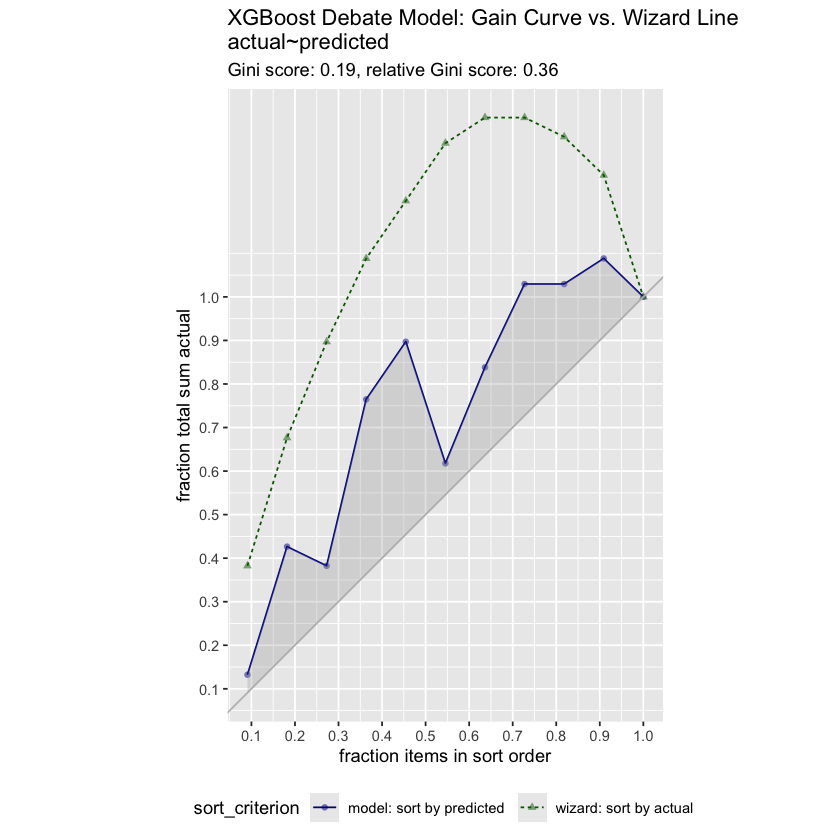

In [580]:
# Gain Curve Plot
GainCurvePlot(
  frame    = final_bias_predictions, 
  xvar     = "predicted", 
  truthVar = "actual", 
  title    = "XGBoost Debate Model: Gain Curve vs. Wizard Line"
)